# Exploratory Data Analysis

The objective of this analysis is to describe and explore the variables of both data sets, as well as to statistically justify the proximity between the measurement tower and the wind farm.

These data sets come from meteorological data on the one hand, and from the energy generation of wind farms on the other. Both are located in the city of Taggenberg, Zurich, Switzerland.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import openmeteo_requests
import requests_cache
from retry_requests import retry

## Measurement of meteorological components

The data was taken from the ["Open-Meteo"](https://open-meteo.com/en/docs/historical-weather-api?latitude=47.5173&longitude=8.6805&hourly=temperature_2m,relative_humidity_2m,dew_point_2m,precipitation,et0_fao_evapotranspiration,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,soil_temperature_100_to_255cm,soil_moisture_100_to_255cm,direct_radiation_instant,terrestrial_radiation_instant,temperature_2m_spread,dew_point_2m_spread,precipitation_spread,direct_radiation_spread,wind_speed_10m_spread,wind_speed_100m_spread,wind_direction_10m_spread,wind_direction_100m_spread,soil_temperature_100_to_255cm_spread,soil_moisture_100_to_255cm_spread&models=best_match&wind_speed_unit=ms) an open-source weather API and offers free access for non-commercial use, It contains the historical data from 1940, with hourly resolution available for any location on earth. 

In [2]:
# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 47.52,
	"longitude": 8.68236,
	"start_date": "2021-12-31",
	"end_date": "2023-07-20",
	"hourly": ["temperature_2m", "wind_speed_10m", "wind_speed_100m", "wind_direction_10m", "wind_direction_100m", "direct_radiation_instant", "temperature_2m_spread", "direct_radiation_spread", "wind_speed_10m_spread", "wind_speed_100m_spread", "wind_direction_10m_spread", "wind_direction_100m_spread", "surface_pressure", "relative_humidity_2m"],
	"models": "best_match",
	"timezone": "auto",
	"wind_speed_unit": "ms",
}
responses = openmeteo.weather_api(url, params=params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(1).ValuesAsNumpy()
hourly_wind_speed_100m = hourly.Variables(2).ValuesAsNumpy()
hourly_wind_direction_10m = hourly.Variables(3).ValuesAsNumpy()
hourly_wind_direction_100m = hourly.Variables(4).ValuesAsNumpy()
hourly_direct_radiation_instant = hourly.Variables(5).ValuesAsNumpy()
hourly_temperature_2m_spread = hourly.Variables(6).ValuesAsNumpy()
hourly_direct_radiation_spread = hourly.Variables(7).ValuesAsNumpy()
hourly_wind_speed_10m_spread = hourly.Variables(8).ValuesAsNumpy()
hourly_wind_speed_100m_spread = hourly.Variables(9).ValuesAsNumpy()
hourly_wind_direction_10m_spread = hourly.Variables(10).ValuesAsNumpy()
hourly_wind_direction_100m_spread = hourly.Variables(11).ValuesAsNumpy()
hourly_surface_pressure = hourly.Variables(12).ValuesAsNumpy()
hourly_relative_humidity_2m = hourly.Variables(13).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	end =  pd.to_datetime(hourly.TimeEnd() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}

hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["wind_speed_10m"] = hourly_wind_speed_10m
hourly_data["wind_speed_100m"] = hourly_wind_speed_100m
hourly_data["wind_direction_10m"] = hourly_wind_direction_10m
hourly_data["wind_direction_100m"] = hourly_wind_direction_100m
hourly_data["direct_radiation_instant"] = hourly_direct_radiation_instant
hourly_data["surface_pressure"] = hourly_surface_pressure
hourly_data["relative_humidity_2m"] = hourly_relative_humidity_2m

hourly_dataframe = pd.DataFrame(data = hourly_data)
df_med = pd.DataFrame(data = hourly_data)
df_med.describe()


Coordinates: 47.48681640625°N 8.71921157836914°E
Elevation: 504.0 m asl
Timezone: b'Europe/Zurich'b'GMT+1'
Timezone difference to GMT+0: 3600s


,temperature_2m,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,direct_radiation_instant,surface_pressure,relative_humidity_2m
count,13608.000000,13608.000000,13608.000000,13608.000000,13608.000000,13608.000000,13608.000000,13608.000000
mean,10.403462,2.671756,4.556638,159.745514,165.070145,104.361481,959.292908,74.844376
std,8.227245,1.504531,2.581734,92.925095,95.881744,187.546509,7.089916,17.246332
min,-13.250000,0.000000,0.000000,1.636545,0.939169,0.000000,926.156921,22.949593
25%,4.000000,1.581139,2.594224,61.699341,61.086610,0.000000,955.670135,62.931815
50%,9.950000,2.416609,4.322613,175.331306,201.159454,0.000000,959.404602,78.314835
75%,16.500000,3.492850,6.168468,235.784241,241.927612,122.303329,963.349014,89.458666
max,34.099998,12.924783,20.753073,360.000000,360.000000,792.444031,978.547485,100.000000


In [3]:
df_med

,date,temperature_2m,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,direct_radiation_instant,surface_pressure,relative_humidity_2m
0,2021-12-31 00:00:00+00:00,8.950000,1.503330,2.483948,176.186005,220.100845,0.000000,965.402222,97.663376
1,2021-12-31 01:00:00+00:00,7.800000,2.022375,4.588028,171.469315,196.460098,0.000000,965.352051,92.436203
2,2021-12-31 02:00:00+00:00,7.150000,2.121320,4.346262,171.869980,203.025528,0.000000,965.310547,94.005936
3,2021-12-31 03:00:00+00:00,6.600000,2.745906,5.141984,169.508575,193.495743,0.000000,965.195251,94.632912
4,2021-12-31 04:00:00+00:00,5.950000,2.158703,4.767599,166.607483,189.659821,0.000000,964.964417,94.935028
...,...,...,...,...,...,...,...,...,...
13603,2023-07-20 19:00:00+00:00,22.100000,2.247220,4.780168,249.145462,254.219177,32.962650,954.883789,53.438427
13604,2023-07-20 20:00:00+00:00,20.299999,1.360147,3.758989,287.102814,298.610352,2.112543,954.829041,65.825829
13605,2023-07-20 21:00:00+00:00,19.200001,1.555635,3.195309,315.000092,339.863586,0.000000,954.997803,73.032852
13606,2023-07-20 22:00:00+00:00,18.400000,1.503330,4.143670,3.814010,8.325568,0.000000,955.033936,64.990074


In [4]:
df_med.dtypes

date                        datetime64[s, UTC]
temperature_2m                         float32
wind_speed_10m                         float32
wind_speed_100m                        float32
wind_direction_10m                     float32
wind_direction_100m                    float32
direct_radiation_instant               float32
surface_pressure                       float32
relative_humidity_2m                   float32
dtype: object

In [5]:
df_med.isnull().sum()

date                        0
temperature_2m              0
wind_speed_10m              0
wind_speed_100m             0
wind_direction_10m          0
wind_direction_100m         0
direct_radiation_instant    0
surface_pressure            0
relative_humidity_2m        0
dtype: int64

### Univariate analysis

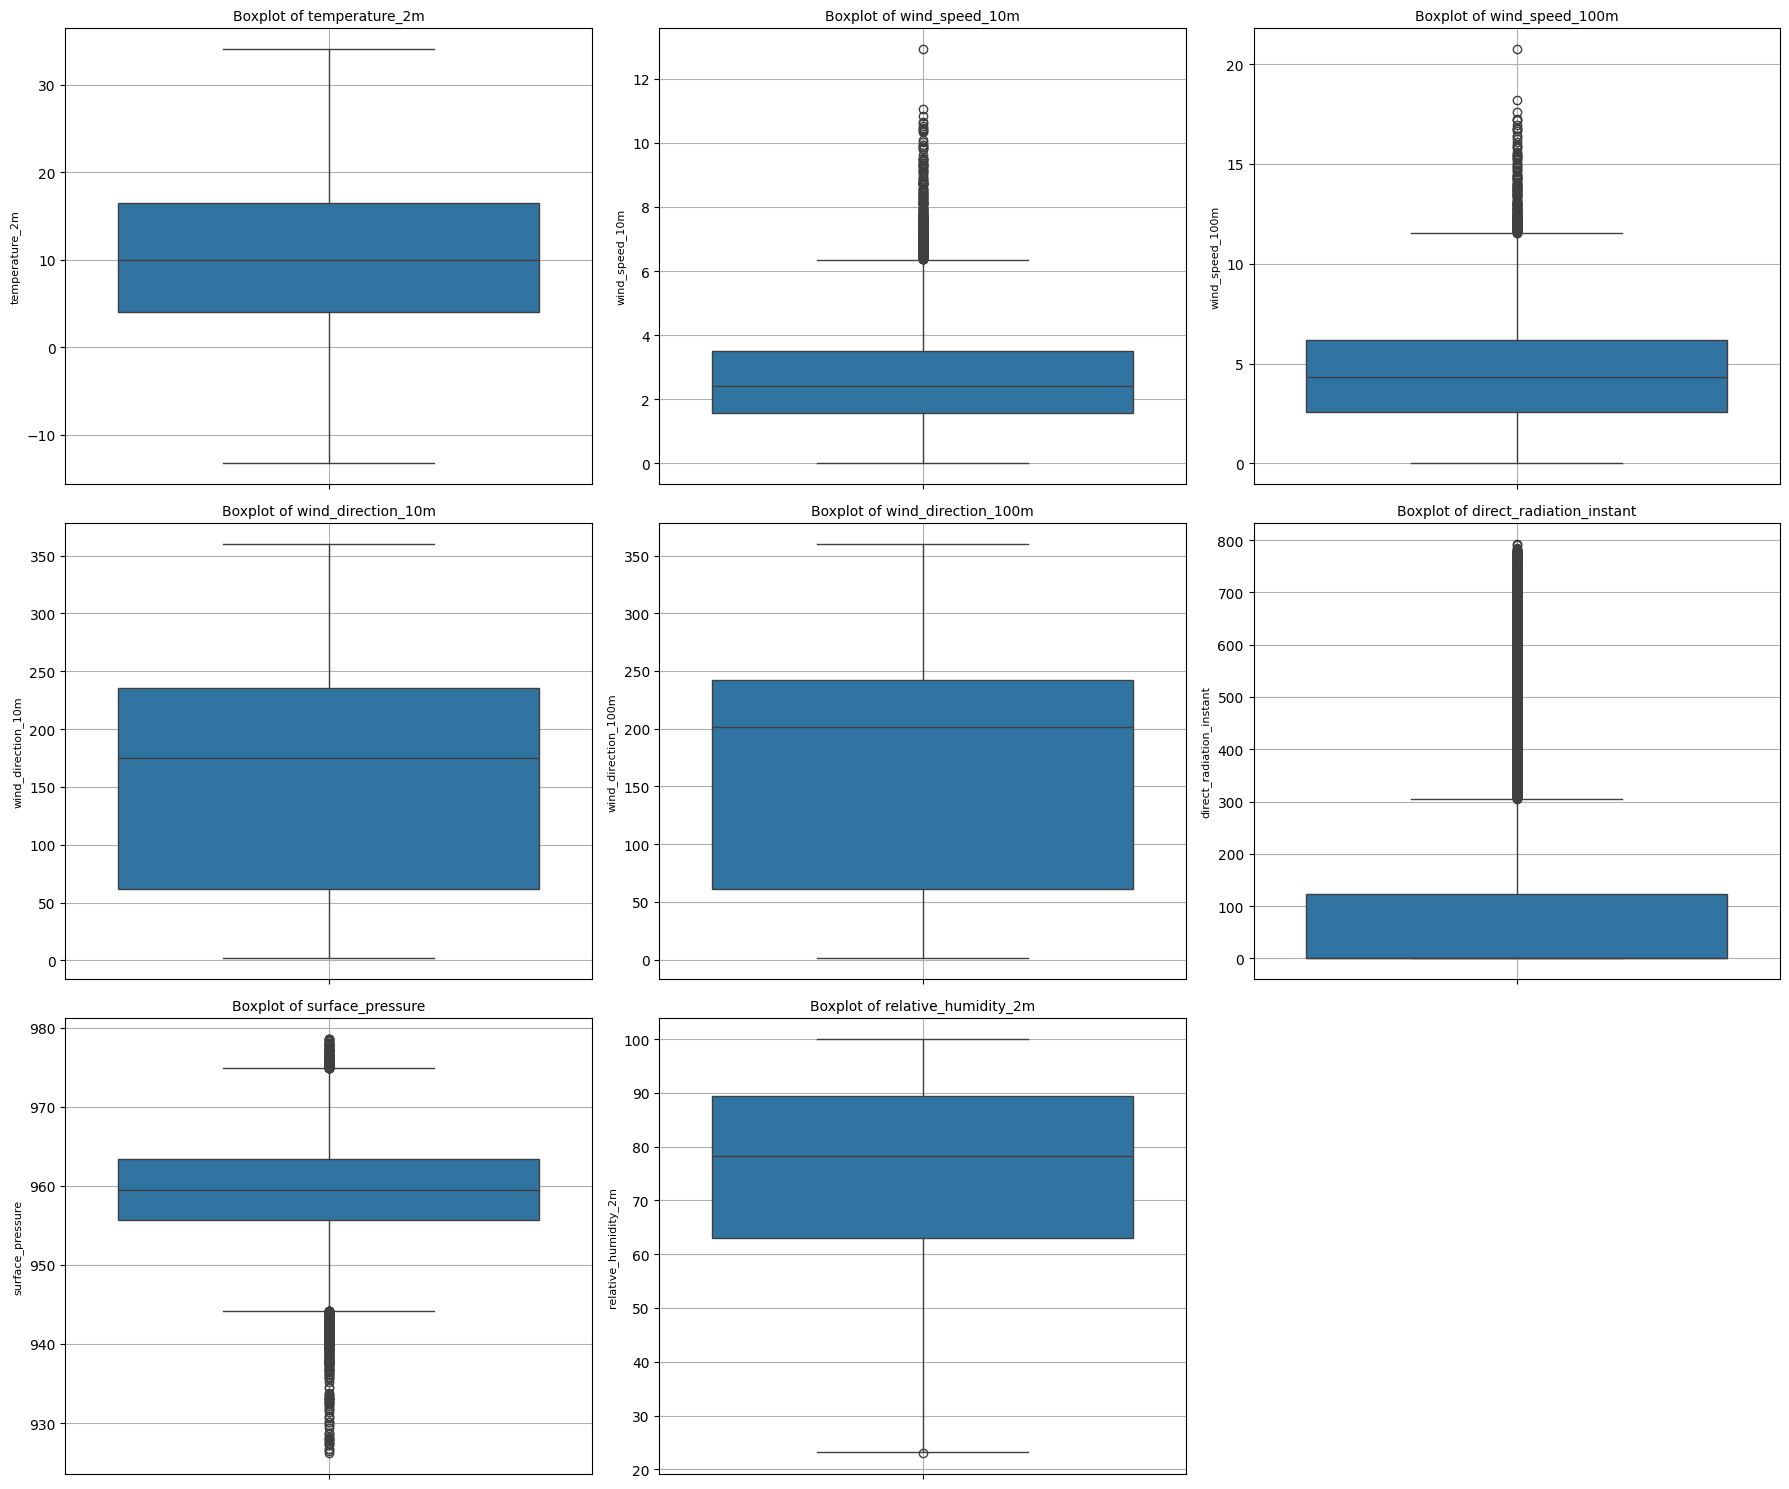

In [6]:
# Generate boxplots for each variable in a grid format
cols = df_med.columns.tolist()
cols.remove('date')

n_cols = 3  # Number of columns in the grid
n_rows = (len(cols) + n_cols - 1) // n_cols  # Calculate the number of rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5)) # Increased figure size
axes = axes.flatten() # Flatten the 2D array of axes for easier indexing

for i, col in enumerate(cols):
    sns.boxplot(data=df_med, y=col, ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}', fontsize=10)
    axes[i].set_ylabel(col, fontsize=8)
    axes[i].grid(True)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Bivariate analysis

The objective variable is the wind speed at 110 meters because it's the average height of a wind turbine for this reason is the main variable that in the studywant to predict.

The bivariate analysus focuses in the relationships between the wind speed at 110 meters and the others metheorological components.

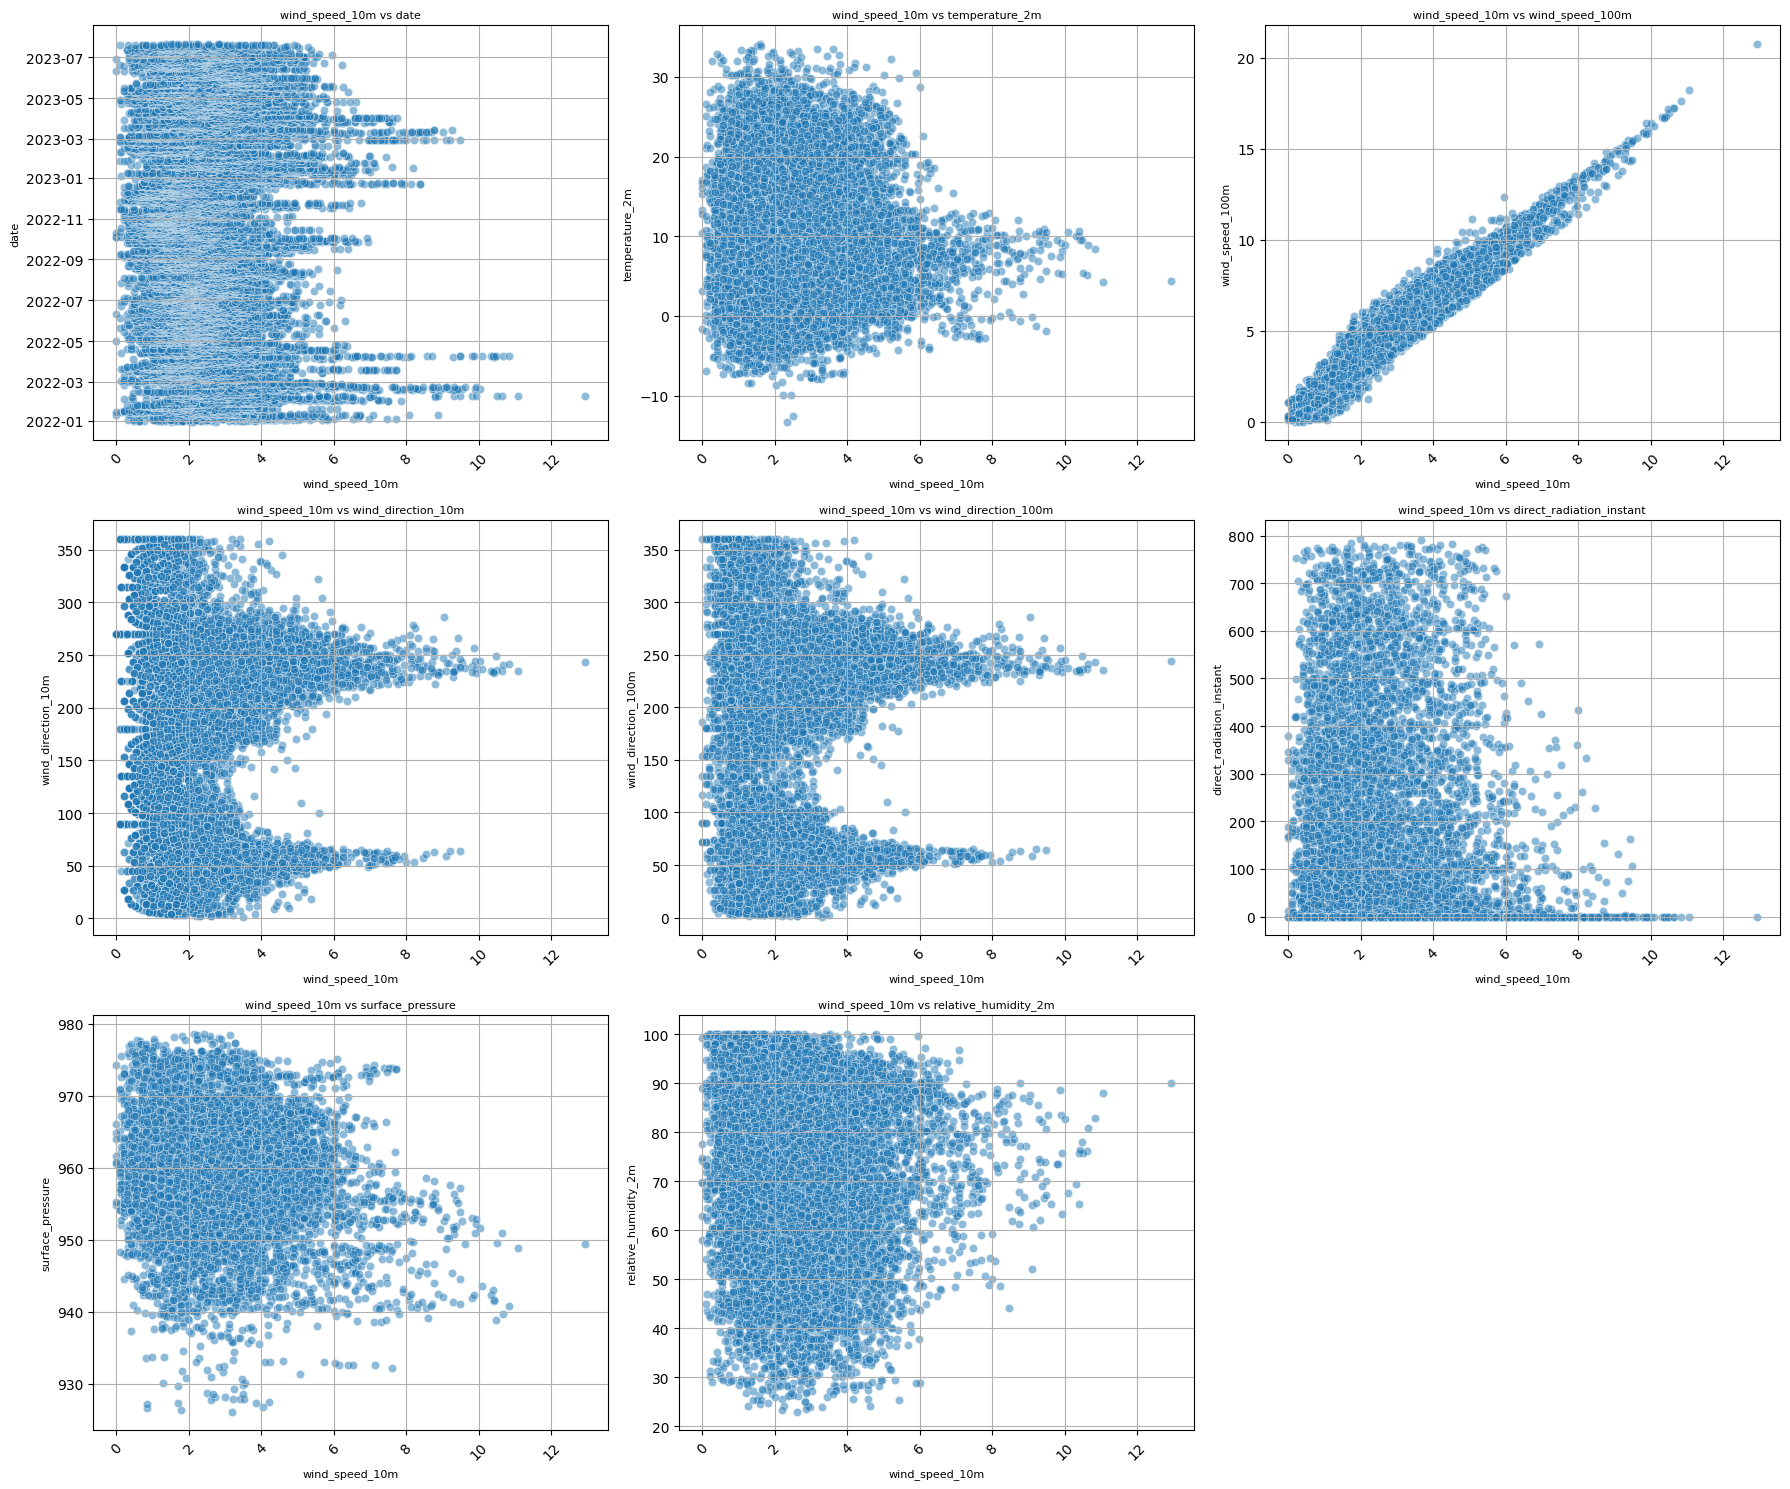

In [7]:
# Generate scatter plots to visualize the relationship between wind speed at 110m and other variables in a grid format
wind_speed_col = 'wind_speed_10m'
other_cols = [col for col in df_med.columns if col != wind_speed_col]

n_cols = 3  # Number of columns in the grid
n_rows = (len(other_cols) + n_cols - 1) // n_cols  # Calculate the number of rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
axes = axes.flatten() # Flatten the 2D array of axes for easier indexing

for i, col in enumerate(other_cols):
    sns.scatterplot(data=df_med, x=wind_speed_col, y=col, alpha=0.5, ax=axes[i])
    axes[i].set_title(f'{wind_speed_col} vs {col}', fontsize=8)
    axes[i].set_xlabel(wind_speed_col, fontsize=8)
    axes[i].set_ylabel(col, fontsize=8)
    axes[i].tick_params(axis='x', rotation=45) # Rotate x-axis labels
    axes[i].grid(True)


# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

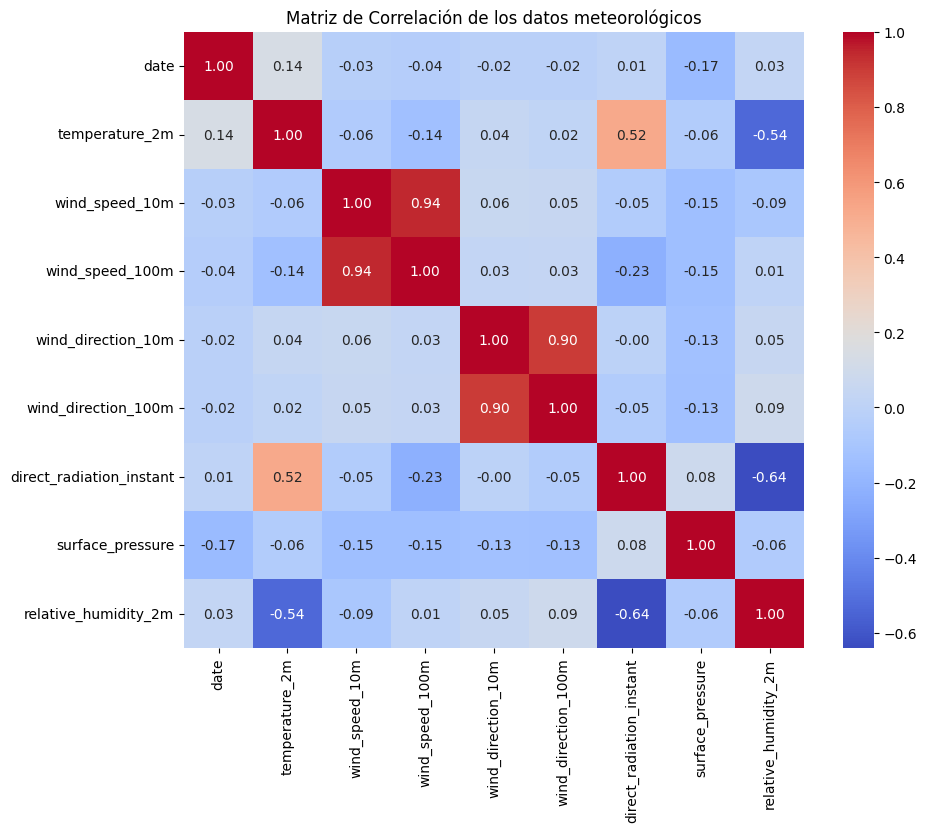

In [8]:
# Calculate the correlation matrix
corr1 = df_med.corr()

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr1, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de los datos meteorológicos')
plt.show()

In [9]:
upper = corr1.where(np.triu(np.ones(corr1.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any((upper[column] > 0.80) & (upper[column] < 1))]
df = df_med.drop(columns=to_drop)

print("Original columns:", df_med.columns)
print("Columns to drop (correlation between 0.8 and 0.9):", to_drop)
print("Remaining columns:", df.columns)

Original columns: Index(['date', 'temperature_2m', 'wind_speed_10m', 'wind_speed_100m',
       'wind_direction_10m', 'wind_direction_100m', 'direct_radiation_instant',
       'surface_pressure', 'relative_humidity_2m'],
      dtype='str')
Columns to drop (correlation between 0.8 and 0.9): ['wind_speed_100m', 'wind_direction_100m']
Remaining columns: Index(['date', 'temperature_2m', 'wind_speed_10m', 'wind_direction_10m',
       'direct_radiation_instant', 'surface_pressure', 'relative_humidity_2m'],
      dtype='str')


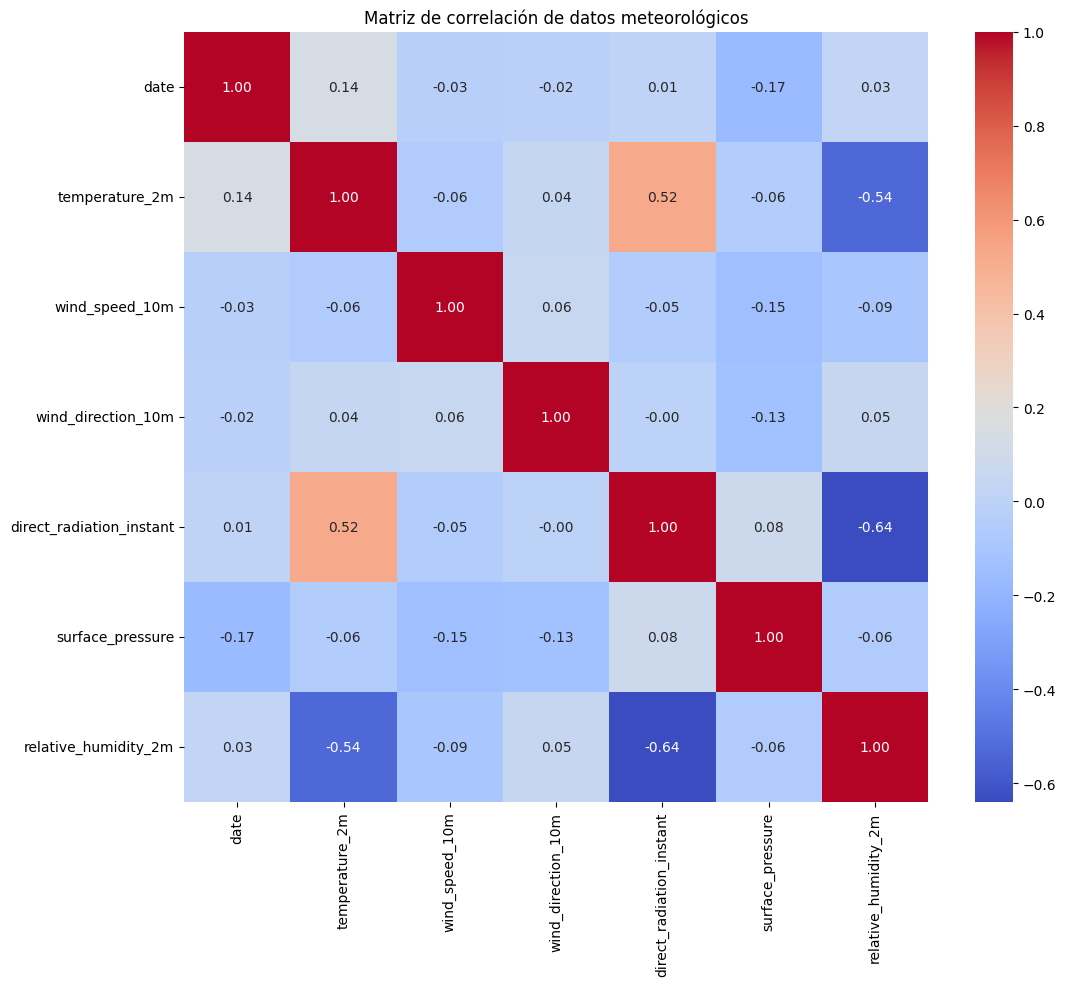

In [10]:
correlation_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlación de datos meteorológicos')
plt.show()

In another code will be perform the attribute analysis for this data set, but now the objective is to justify the use of one or other measurement data.

## Measurement of wind power generation

The data of the real generation of wind turbines was taken from the National electricity Sistem, SEN in spanish, [web page](https://https://www.coordinador.cl/operacion/graficos/operacion-real/generacion-real/). SEN is the entity that unifies the electricity of Chile.

This thesis uses the data from the wind farms closest to the measurement tower, that it the wind farms that are in the national reserve or near to Taltal, that's in the Antofagasta region

In [11]:
df_gen = pd.read_csv(r'C:\Users\agrom\OneDrive\Desktop\CodigoTesis\Aventa_AV7_IET_OST_SCADA.csv')
df_gen.drop(columns=['GeneratorSpeed', 'GeneratorTemperature', 'SpeiseSpannung', 'StatusAnlage', 'MaxWindHeute', 'offsetWindDirection'], inplace= True)
df_gen.head()

,Datetime,RotorSpeed,WindSpeed,PowerOutput,PitchDeg
0,2021-12-31 23:00:00.647,0.0,0.0,0.0,80.313994
1,2021-12-31 23:00:01.647,0.0,0.0,0.0,80.313994
2,2021-12-31 23:00:02.647,0.0,0.0,0.0,80.313994
3,2021-12-31 23:00:03.650,0.0,0.0,0.0,80.313994
4,2021-12-31 23:00:04.650,0.0,0.0,0.0,80.313994


In [12]:
df_gen.describe(include='all')

,Datetime,RotorSpeed,WindSpeed,PowerOutput,PitchDeg
count,39715978,3.971598e+07,3.971598e+07,3.971598e+07,3.971598e+07
unique,39715978,NaN,NaN,NaN,NaN
top,2021-12-31 23:00:00.647,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN
mean,NaN,2.067616e+01,2.457526e+00,1.051422e+00,3.227648e+01
std,NaN,2.260638e+01,2.324517e+00,1.957080e+00,2.142140e+01
min,NaN,0.000000e+00,0.000000e+00,-2.200000e-01,1.360799e+01
25%,NaN,0.000000e+00,1.000000e+00,0.000000e+00,1.403400e+01
50%,NaN,1.060000e+01,1.900000e+00,0.000000e+00,3.785894e+01
75%,NaN,3.790000e+01,3.200000e+00,1.050000e+00,3.819185e+01


In [55]:
df_gen.isnull().sum()

Datetime       0
RotorSpeed     0
WindSpeed      1
PowerOutput    1
PitchDeg       1
dtype: int64

In [56]:
df_gen.dropna(subset=['WindSpeed', 'PowerOutput', 'PitchDeg'], inplace=True)
# 1. Definimos la agregación
df_gen['Datetime'] = pd.to_datetime(df_gen['Datetime'])
df_gen = df_gen.set_index('Datetime')

df_gen['sin_pitch'] = np.sin(np.radians(df_gen['PitchDeg']))
df_gen['cos_pitch'] = np.cos(np.radians(df_gen['PitchDeg']))
df_gen = df_gen.drop(columns='PitchDeg')
ag = {
    'RotorSpeed': 'mean',
    'WindSpeed': 'mean',
    'PowerOutput': 'sum',
    #'PowerOutput': 'mean',
    'sin_pitch': 'mean',
    'cos_pitch': 'mean' 
}

# 2. Resamplear
df_h = df_gen.resample('1h').agg(ag)
df_h = df_h.reset_index()
# 3. ELIMINAR LOS HUECOS (Nulos generados por falta de registros)
# Esto borrará las horas donde no hubo datos originales.
df_h = df_h.dropna()
# 4. Cálculo del Pitch Final
df_h['PitchDeg_Mean'] = np.degrees(np.arctan2(df_h['sin_pitch'], df_h['cos_pitch'])) % 360

# 5. Limpieza final de columnas auxiliares
df_h = df_h.drop(columns=['sin_pitch', 'cos_pitch'])

df_h['PowerOutput'] /= 3600 

print(df_h.describe())

                         Datetime    RotorSpeed     WindSpeed   PowerOutput  \
count                       11912  11912.000000  11912.000000  11912.000000   
mean   2022-10-15 19:18:37.293485     21.783351      2.528212      0.973767   
min           2021-12-31 23:00:00      0.000000      0.000000     -0.043153   
25%           2022-05-11 03:45:00      0.000278      1.086410      0.000000   
50%           2022-10-31 15:30:00     16.098900      1.944064      0.109803   
75%           2023-03-12 09:15:00     38.949664      3.360289      1.019128   
max           2023-07-20 21:00:00     65.896111     16.745614      6.877236   
std                           NaN     21.836371      2.169191      1.701793   

       PitchDeg_Mean  
count   11912.000000  
mean       31.599770  
min        14.034000  
25%        14.646029  
50%        26.571437  
75%        38.191855  
max        80.718554  
std        20.093799  


### Univariate analysis

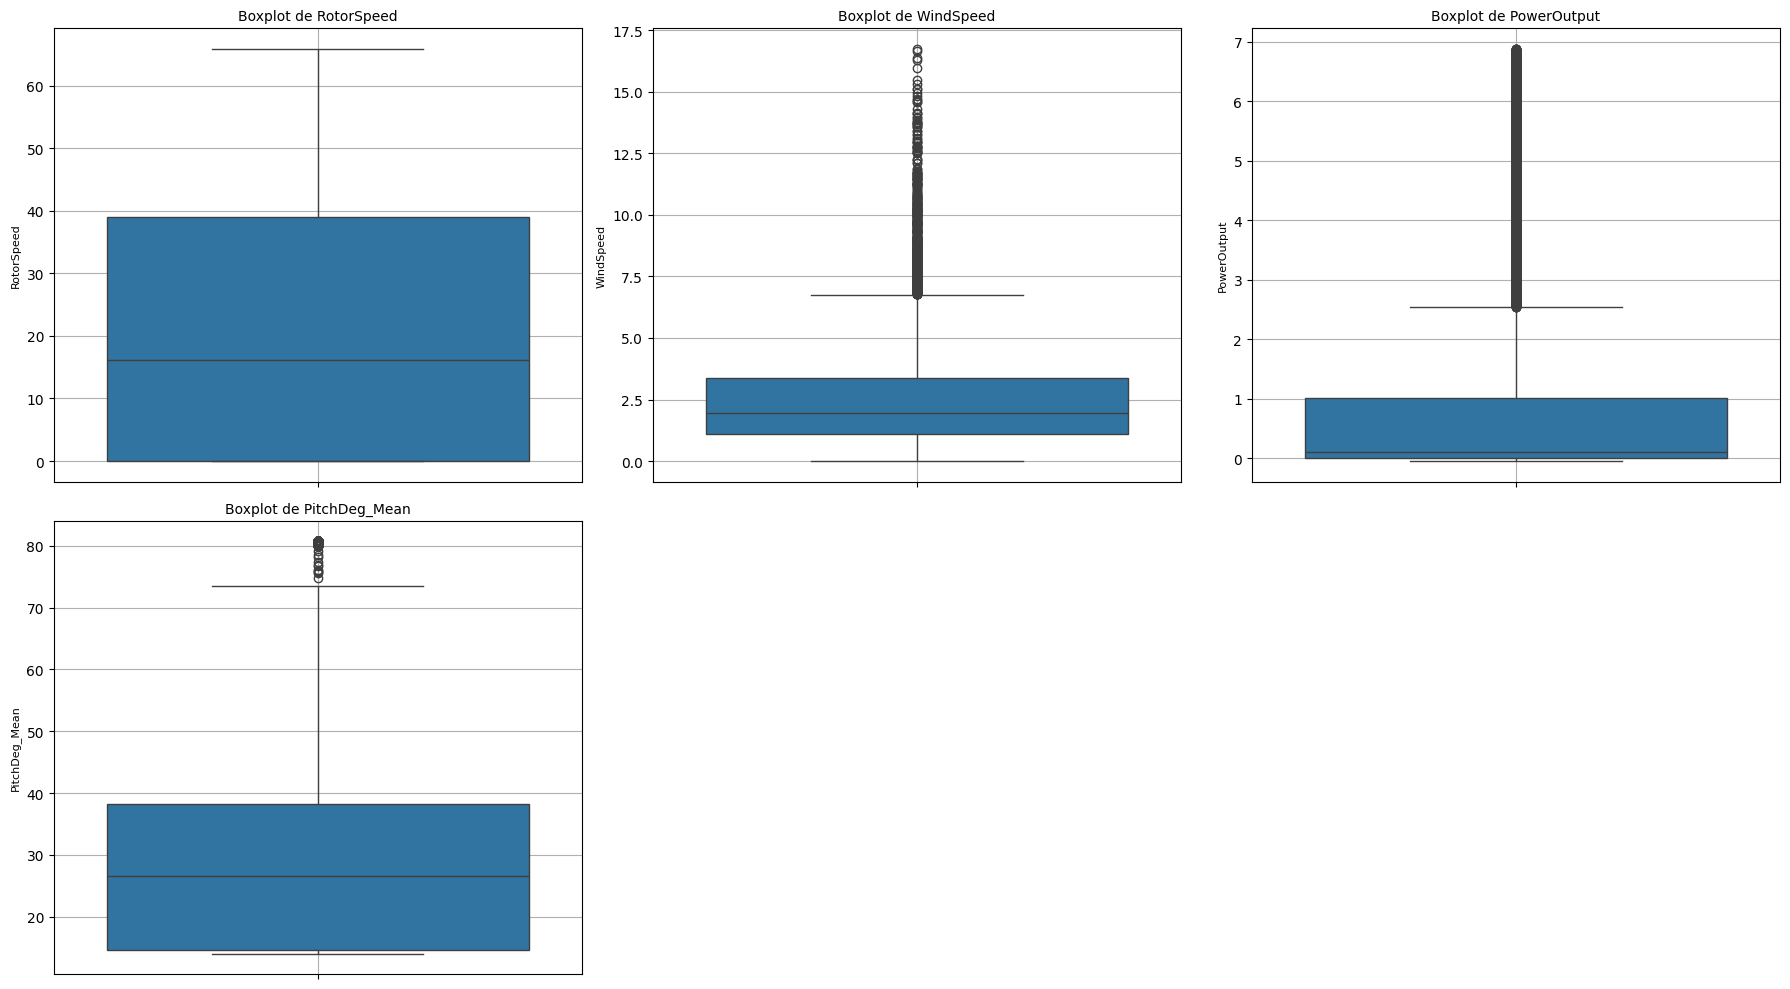

In [57]:
# Generate boxplots for each variable in a grid format
cols = df_h.columns.tolist()
cols.remove('Datetime') # Remove non-numerical column

n_cols = 3  # Number of columns in the grid
n_rows = (len(cols) + n_cols - 1) // n_cols  # Calculate the number of rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5)) # Increased figure size
axes = axes.flatten() # Flatten the 2D array of axes for easier indexing

for i, col in enumerate(cols):
    sns.boxplot(data=df_h, y=col, ax=axes[i])
    axes[i].set_title(f'Boxplot de {col}', fontsize=10)
    axes[i].set_ylabel(col, fontsize=8)
    axes[i].grid(True)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Bivariate analysis

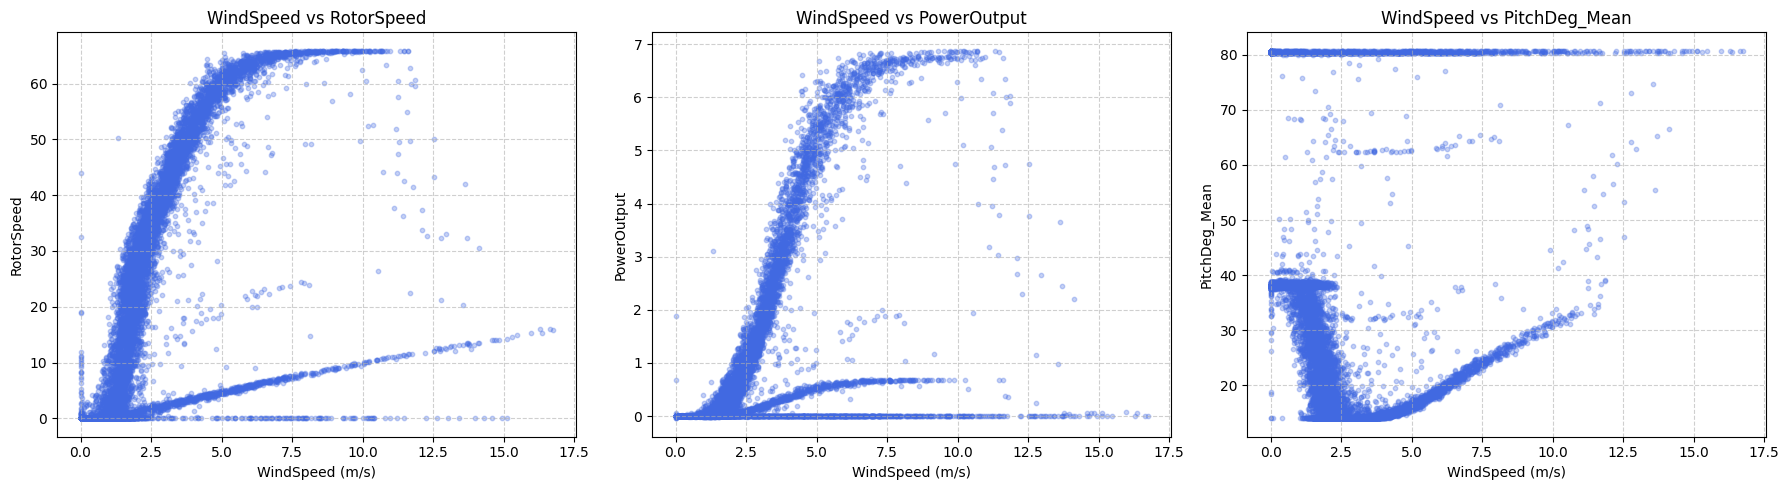

In [58]:
columnas_y = ['RotorSpeed', 'PowerOutput', 'PitchDeg_Mean']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

for i, col in enumerate(columnas_y):
    axes[i].scatter(df_h['WindSpeed'], df_h[col], alpha=0.3, s=10, color='royalblue')
    
    axes[i].set_title(f'WindSpeed vs {col}')
    axes[i].set_xlabel('WindSpeed (m/s)')
    axes[i].set_ylabel(col)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

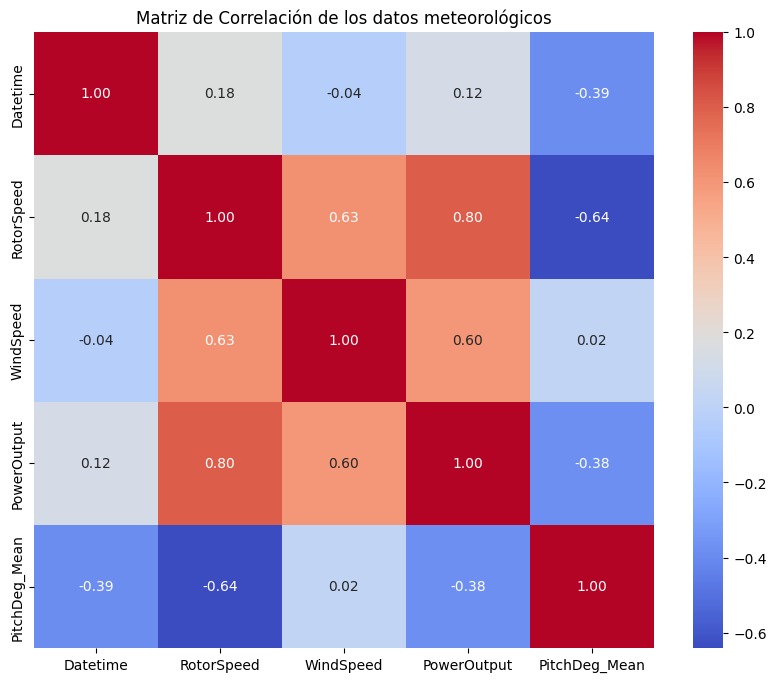

In [59]:
# Calculate the correlation matrix
corr1 = df_h.corr()

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr1, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de los datos meteorológicos')
plt.show()

#Merge metheorological data with operational data

In [60]:
# Quitar la zona horaria del dataset que la tiene (+00:00)
# .dt.tz_localize(None) la convierte en una fecha "normal"
df['Datetime'] = pd.to_datetime(df['date']).dt.tz_localize(None)
df.drop(columns=['date'], inplace=True)
# Asegurar que el segundo también sea datetime
df_h['Datetime'] = pd.to_datetime(df_h['Datetime'])


# 2. Filtrar para que empiece exactamente a las 23:00 del 2021-12-31
# Esto elimina los datos previos de ese día
df = df[df['Datetime'] >= '2021-12-31 23:00:00']

# 4. Unir ambos datasets
# Usamos 'inner' para que solo queden las horas donde AMBOS tienen datos
df_estudio = pd.merge(df_h, df, on='Datetime', how='inner')

In [61]:
df_estudio.describe()

,Datetime,RotorSpeed,WindSpeed,PowerOutput,PitchDeg_Mean,temperature_2m,wind_speed_10m,wind_direction_10m,direct_radiation_instant,surface_pressure,relative_humidity_2m
count,11912,11912.000000,11912.000000,11912.000000,11912.000000,11912.000000,11912.000000,11912.000000,11912.000000,11912.000000,11912.000000
mean,2022-10-15 19:18:37.293485,21.783351,2.528212,0.973767,31.599770,9.767231,2.723572,160.952362,98.335197,959.146057,75.309746
min,2021-12-31 23:00:00,0.000000,0.000000,-0.043153,14.034000,-7.200000,0.000000,1.636545,0.000000,926.156921,23.955673
25%,2022-05-11 03:45:00,0.000278,1.086410,0.000000,14.646029,3.650000,1.612452,62.102829,0.000000,955.489136,63.822680
50%,2022-10-31 15:30:00,16.098900,1.944064,0.109803,26.571437,9.050000,2.469818,180.000000,0.000000,959.299225,78.740162
75%,2023-03-12 09:15:00,38.949664,3.360289,1.019128,38.191855,15.450000,3.569314,235.713074,106.305447,963.233154,89.509481
max,2023-07-20 21:00:00,65.896111,16.745614,6.877236,80.718554,33.549999,12.924783,360.000000,789.811401,978.547485,100.000000
std,NaN,21.836371,2.169191,1.701793,20.093799,7.917434,1.544116,91.922279,181.531738,7.182381,16.856661


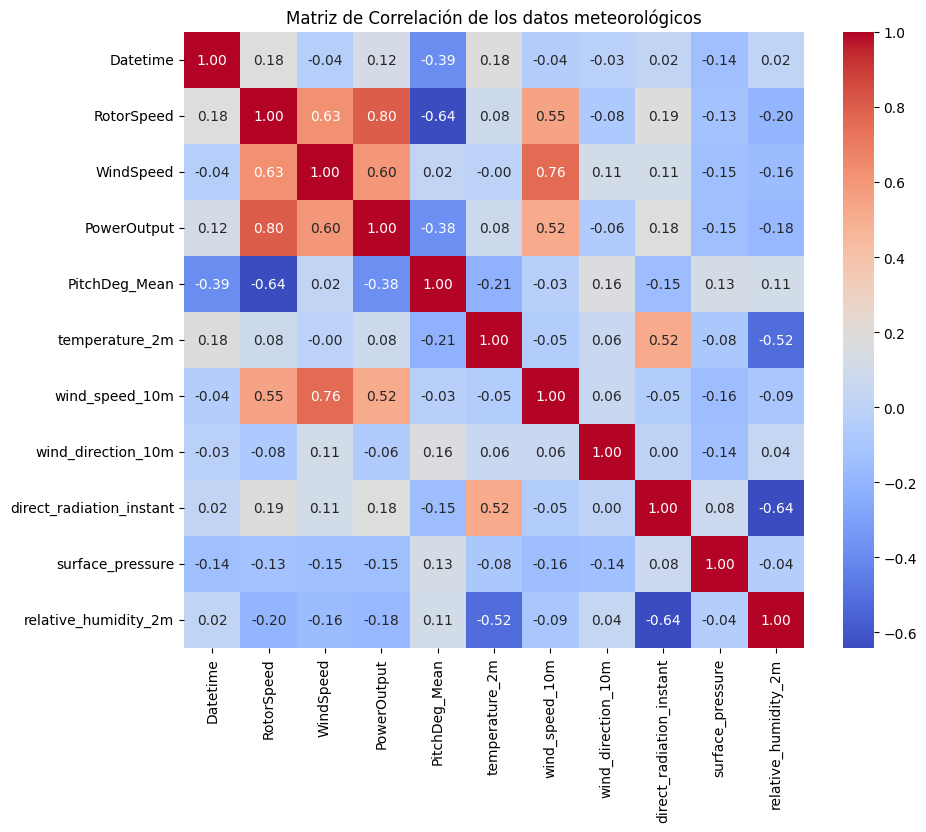

In [62]:
# Calculate the correlation matrix
corr1 = df_estudio.corr()

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr1, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de los datos meteorológicos')
plt.show()

In [63]:
df_estudio.to_csv(r'C:\Users\agrom\OneDrive\Desktop\CodigoTesis\Datos_Tesis_SW.csv', index=False)